<a href="https://colab.research.google.com/github/cutiips/OverfittingRepo/blob/main/03-Marquis_Aris_Singh_Curty_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Phase d'idéation

In [1]:
# TODO : importer le fichier useCase.md pour expliquer le use case dans le notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from scipy import stats
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.graphics.gofplots import ProbPlot

# 1. Phase d'idéation

Début de la phase d'idéation par une analyse exploratoire (EDA) du dataset.

Les points analysés sont les suivants :
- Présence des valeurs manquantes
- Types de variables présentes

In [3]:
# Chargement des fichiers train et test
df = pd.read_csv("data/train.csv")

df['LogSalePrice'] = np.log1p(df['SalePrice'])

test_df = pd.read_csv("data/test.csv")

# Aperçu du dataset
print(f"Shape : {df.shape}")
df.head()

Shape : (1460, 82)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LogSalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,12.247699
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,12.109016
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,12.317171
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,11.849405
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,12.429220


## 1.1 Analyse des valeurs manquantes

Nous identifions les colonnes avec des valeurs manquantes pour préparer un futur traitement des données (imputation ou suppression).


In [4]:
# Aperçu initial des données
print("1.1 Analyse des valeurs manquantes")

train_overview = {
    "shape": df.shape,
    "columns": df.columns.tolist(),
    "missing_values": df.isnull().sum().sort_values(ascending=False).head(20),
    "data_types": df.dtypes.value_counts(),
    "target_description": df['SalePrice'].describe()
}

print("Top 20 colonnes avec valeurs manquantes :")
print(df.isnull().sum().sort_values(ascending=False).head(20))

train_overview

1.1 Analyse des valeurs manquantes
Top 20 colonnes avec valeurs manquantes :
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageYrBlt       81
GarageFinish      81
GarageType        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
MasVnrArea         8
Electrical         1
HouseStyle         0
dtype: int64


{'shape': (1460, 82),
 'columns': ['Id',
  'MSSubClass',
  'MSZoning',
  'LotFrontage',
  'LotArea',
  'Street',
  'Alley',
  'LotShape',
  'LandContour',
  'Utilities',
  'LotConfig',
  'LandSlope',
  'Neighborhood',
  'Condition1',
  'Condition2',
  'BldgType',
  'HouseStyle',
  'OverallQual',
  'OverallCond',
  'YearBuilt',
  'YearRemodAdd',
  'RoofStyle',
  'RoofMatl',
  'Exterior1st',
  'Exterior2nd',
  'MasVnrType',
  'MasVnrArea',
  'ExterQual',
  'ExterCond',
  'Foundation',
  'BsmtQual',
  'BsmtCond',
  'BsmtExposure',
  'BsmtFinType1',
  'BsmtFinSF1',
  'BsmtFinType2',
  'BsmtFinSF2',
  'BsmtUnfSF',
  'TotalBsmtSF',
  'Heating',
  'HeatingQC',
  'CentralAir',
  'Electrical',
  '1stFlrSF',
  '2ndFlrSF',
  'LowQualFinSF',
  'GrLivArea',
  'BsmtFullBath',
  'BsmtHalfBath',
  'FullBath',
  'HalfBath',
  'BedroomAbvGr',
  'KitchenAbvGr',
  'KitchenQual',
  'TotRmsAbvGrd',
  'Functional',
  'Fireplaces',
  'FireplaceQu',
  'GarageType',
  'GarageYrBlt',
  'GarageFinish',
  'GarageC

### 1.1.1 Netttoyage des données

In [5]:
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']
df[cols_none] = df[cols_none].fillna('None')

cols_median = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'GarageCars', 'GarageArea']
for col in cols_median:
    df[col] = df[col].fillna(df[col].median())

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])


---

## 1.2 Types de variables

Nous comptons le nombre de variables de type numérique (`int`, `float`) et catégoriel (`object`).

In [6]:
print("1.2 Types de variables")
df.dtypes.value_counts()

1.2 Types de variables


object     43
int64      35
float64     4
Name: count, dtype: int64

---

## 1.3 Analyse de la distribution de la cible `SalePrice`

La variable cible `SalePrice` est la valeur que nous voulons prédire.
Analysons sa distribution pour comprendre sa répartition, la présence de skewness (asymétrie) ou d'outliers éventuels.


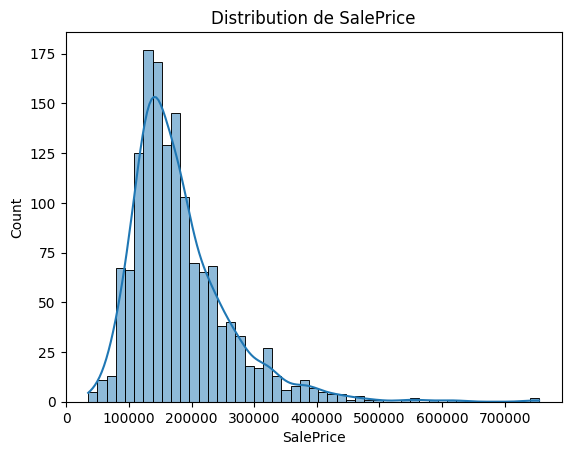

In [7]:
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribution de SalePrice")
plt.show()

### 1.3.1 Test de Shapiro-Wilk

Shapiro-Wilk test statistic: 0.8697
p-value: 0.0000
Avec α = 0.05, on rejette l'hypothèse nulle : la distribution n'est pas normale.


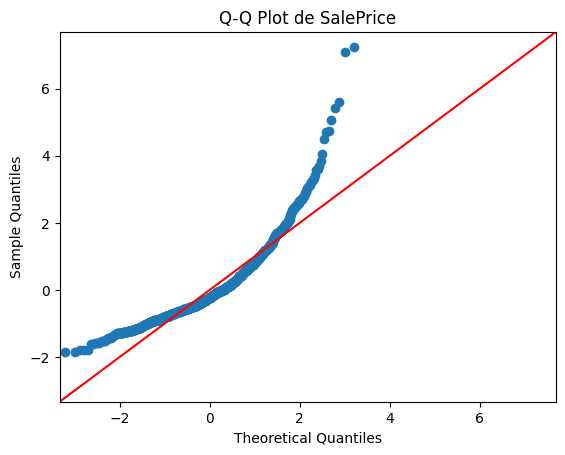

In [8]:
# Test de Shapiro-Wilk
alpha = 0.05
W, p = stats.shapiro(df['SalePrice'])

print(f"Shapiro-Wilk test statistic: {W:.4f}")
print(f"p-value: {p:.4f}")

if p < alpha:
    print(f"Avec α = {alpha}, on rejette l'hypothèse nulle : la distribution n'est pas normale.")
else:
    print(f"Avec α = {alpha}, on ne rejette pas l'hypothèse nulle : la distribution semble normale.")

# Affichage du Q-Q plot
qqplot(df['SalePrice'], dist=stats.norm, fit=True, line='45')
plt.title("Q-Q Plot de SalePrice")
plt.show()

Le prix de vente n’est pas distribué de façon normale, ce qui signifie que l’on a une concentration de maisons autour d’un certain prix médian avec quelques biens très chers. Cela confirme qu’une transformation (ex: log) pourrait stabiliser la variance pour la modélisation.

### 1.3.2 Observations sur `SalePrice`


L’analyse de la distribution de la variable cible SalePrice, qui représente le prix de vente final des maisons, révèle plusieurs éléments importants :

La distribution est asymétrique à droite (right-skewed), ce qui signifie que la majorité des maisons sont vendues à un prix relativement bas à modéré, tandis qu’un petit nombre de biens atteignent des prix très élevés. Ainsi, on remarque visuellement une longue « queue » sur la droite de l’histogramme. La plupart des transactions de vente se situent dans une plage de 100 000 € à 250 000 €, ce qui semble correspondre au cœur du marché résidentiel local. On peut observer un pic de vente autour de 150 000 €, ce qui pourrait correspondre à un prix standard (maisons de taille moyenne avec prestations classiques).

Par contre, on peut remarquer que certaines maisons sont vendues à plus de 500 000 €, voire plus de 700 000 €. Ces valeurs extrêmes, bien que rares, peuvent influencer négativement les modèles statistiques si elles ne sont pas traitées correctement. Ces outliers méritent donc une attention particulière en phase de modélisation.

Cette asymétrie est importante à considérer pour les modèles de machine learning, en particulier ceux qui supposent une distribution gaussienne (comme la régression linéaire, qui fonctionne mieux avec des résidus normalement distribués). Une transformation logarithmique de SalePrice (par exemple via log1p(SalePrice)) est souvent pratiquée pour réduire la skewness (asymétrie), car il faut éviter que le modèle soit trop influencé par les maisons très (trop ?) chères du dataset.

Pour corriger cette asymétrie, on peut envisager de transformer les prix avec une fonction logarithmique, comme log(SalePrice). Pourquoi utiliser le logarithme ? Car il permet de réduire l’impact des maisons très chères (les très grands prix sont "compressés", ce qui équilibre un peu mieux la distribution), de stabiliser la variance (les différences de prix sont ramenées à des écarts relatifs plus homogènes), et d'améliorer les relations entre variables (les liens entre les caractéristiques (surface, qualité, etc.) et le prix sont souvent plus linéaires après transformation, ce qui aide le modèle à mieux apprendre). Il faudra y penser lors des prochaines étapes.


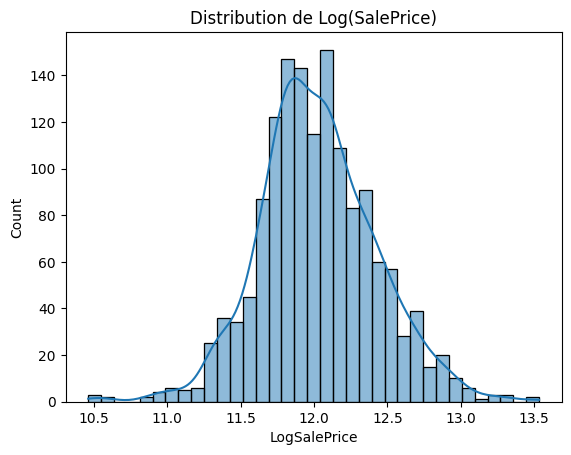

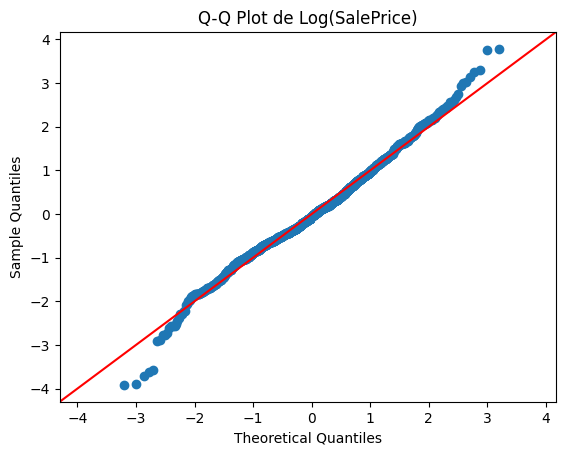

In [9]:
df['LogSalePrice'] = np.log1p(df['SalePrice'])  # Transformation log

# Visualisation
sns.histplot(df['LogSalePrice'], kde=True)
plt.title("Distribution de Log(SalePrice)")
plt.show()

from statsmodels.graphics.gofplots import qqplot
from scipy import stats
qqplot(df['LogSalePrice'], dist=stats.norm, fit=True, line='45')
plt.title("Q-Q Plot de Log(SalePrice)")
plt.show()


### 1.3.3 Transformation logarithmique
Après la transformation logarithmique, la distribution du prix semble plus symétrique et plus proche de la normale. Cette version transformée sera utilisée comme variable cible (target) dans nos modèles.

---

## 1.4 Corrélations principales avec SalePrice

Nous analysons ici les corrélations entre `SalePrice` (le prix de vente brut) et les variables numériques du jeu de données.

Cette analyse permet d’identifier les variables qui entretiennent les liens linéaires les plus forts avec le prix d’une maison, ce qui est utile pour orienter la sélection des features dans les futurs modèles de prédiction.

Cependant, comme `SalePrice` présente une forte asymétrie, il est également pertinent de comparer ces résultats à ceux obtenus avec une version transformée du prix (`LogSalePrice`), mieux adaptée aux modèles linéaires classiques.

Nous afficherons donc les deux types de corrélation :
- Avec le prix brut (`SalePrice`) — utile pour l’interprétation métier.
- Avec le prix transformé (`LogSalePrice`) — utile pour les modèles de régression.


In [10]:
# Corrélations avec SalePrice (brut)
print("Top corrélations avec SalePrice (prix brut)")
print(df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(10))

# Corrélations avec LogSalePrice (pour modélisation)
print("\nTop corrélations avec LogSalePrice (log transformé)")
print(df.corr(numeric_only=True)['LogSalePrice'].sort_values(ascending=False).head(10))

Top corrélations avec SalePrice (prix brut)
SalePrice       1.000000
LogSalePrice    0.948374
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
Name: SalePrice, dtype: float64

Top corrélations avec LogSalePrice (log transformé)
LogSalePrice    1.000000
SalePrice       0.948374
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
Name: LogSalePrice, dtype: float64


## 1.4.1 Observations sur les corrélations

### Corrélation avec SalePrice (prix brut)

Les résultats confirment que la variable OverallQual (qualité générale de la maison) est celle qui entretient la plus forte corrélation avec SalePrice. Cela montre que l’évaluation qualitative d’un bien par un professionnel impacte significativement sa valeur.

On retrouve ensuite GrLivArea (surface habitable hors sous-sol), GarageCars et GarageArea, qui représentent respectivement la capacité de stationnement et la taille du garage. Cela suggère qu’un espace de vie plus grand et des équipements pratiques augmentent nettement la valeur perçue d’une maison.

D’autres variables comme TotalBsmtSF et 1stFlrSF (superficies du sous-sol et du rez-de-chaussée), FullBath et TotRmsAbvGrd (nombre de salles de bains et de pièces au-dessus du sol) indiquent également qu’un espace global plus vaste est un facteur de valorisation.

### Corrélation avec LogSalePrice (prix transformé)

La transformation logarithmique du prix permet de lisser la distribution et d’atténuer l’influence des valeurs extrêmes. Cela améliore la linéarité des relations entre les variables numériques et la cible, ce qui est particulièrement utile pour la régression.

Les variables les plus corrélées restent globalement les mêmes, mais certaines voient leur influence renforcée. Par exemple, OverallQual voit sa corrélation augmenter légèrement. GarageCars, GarageArea et FullBath se confirment comme des indicateurs importants.

YearBuilt (année de construction) gagne aussi en importance dans cette version transformée, ce qui indique que l’ancienneté du logement influence davantage le prix de façon relative que brute.

### Conclusion

Les variables comme OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, FullBath et YearBuilt ressortent comme des facteurs prédictifs essentiels. Elles seront de bons candidats pour constituer un premier modèle de régression linéaire. L’utilisation de LogSalePrice comme cible est justifiée par sa distribution plus symétrique et ses corrélations plus stables avec les features.


---

## 1.5 Analyse des principales variables numériques

Nous visualisons la relation entre `LogSalePrice` et les principales variables numériques identifiées précédemment.
Cela permet de mieux comprendre leur impact et de détecter d’éventuelles non-linéarités.


4. Analyse des principales variables numériques avec LogSalePrice


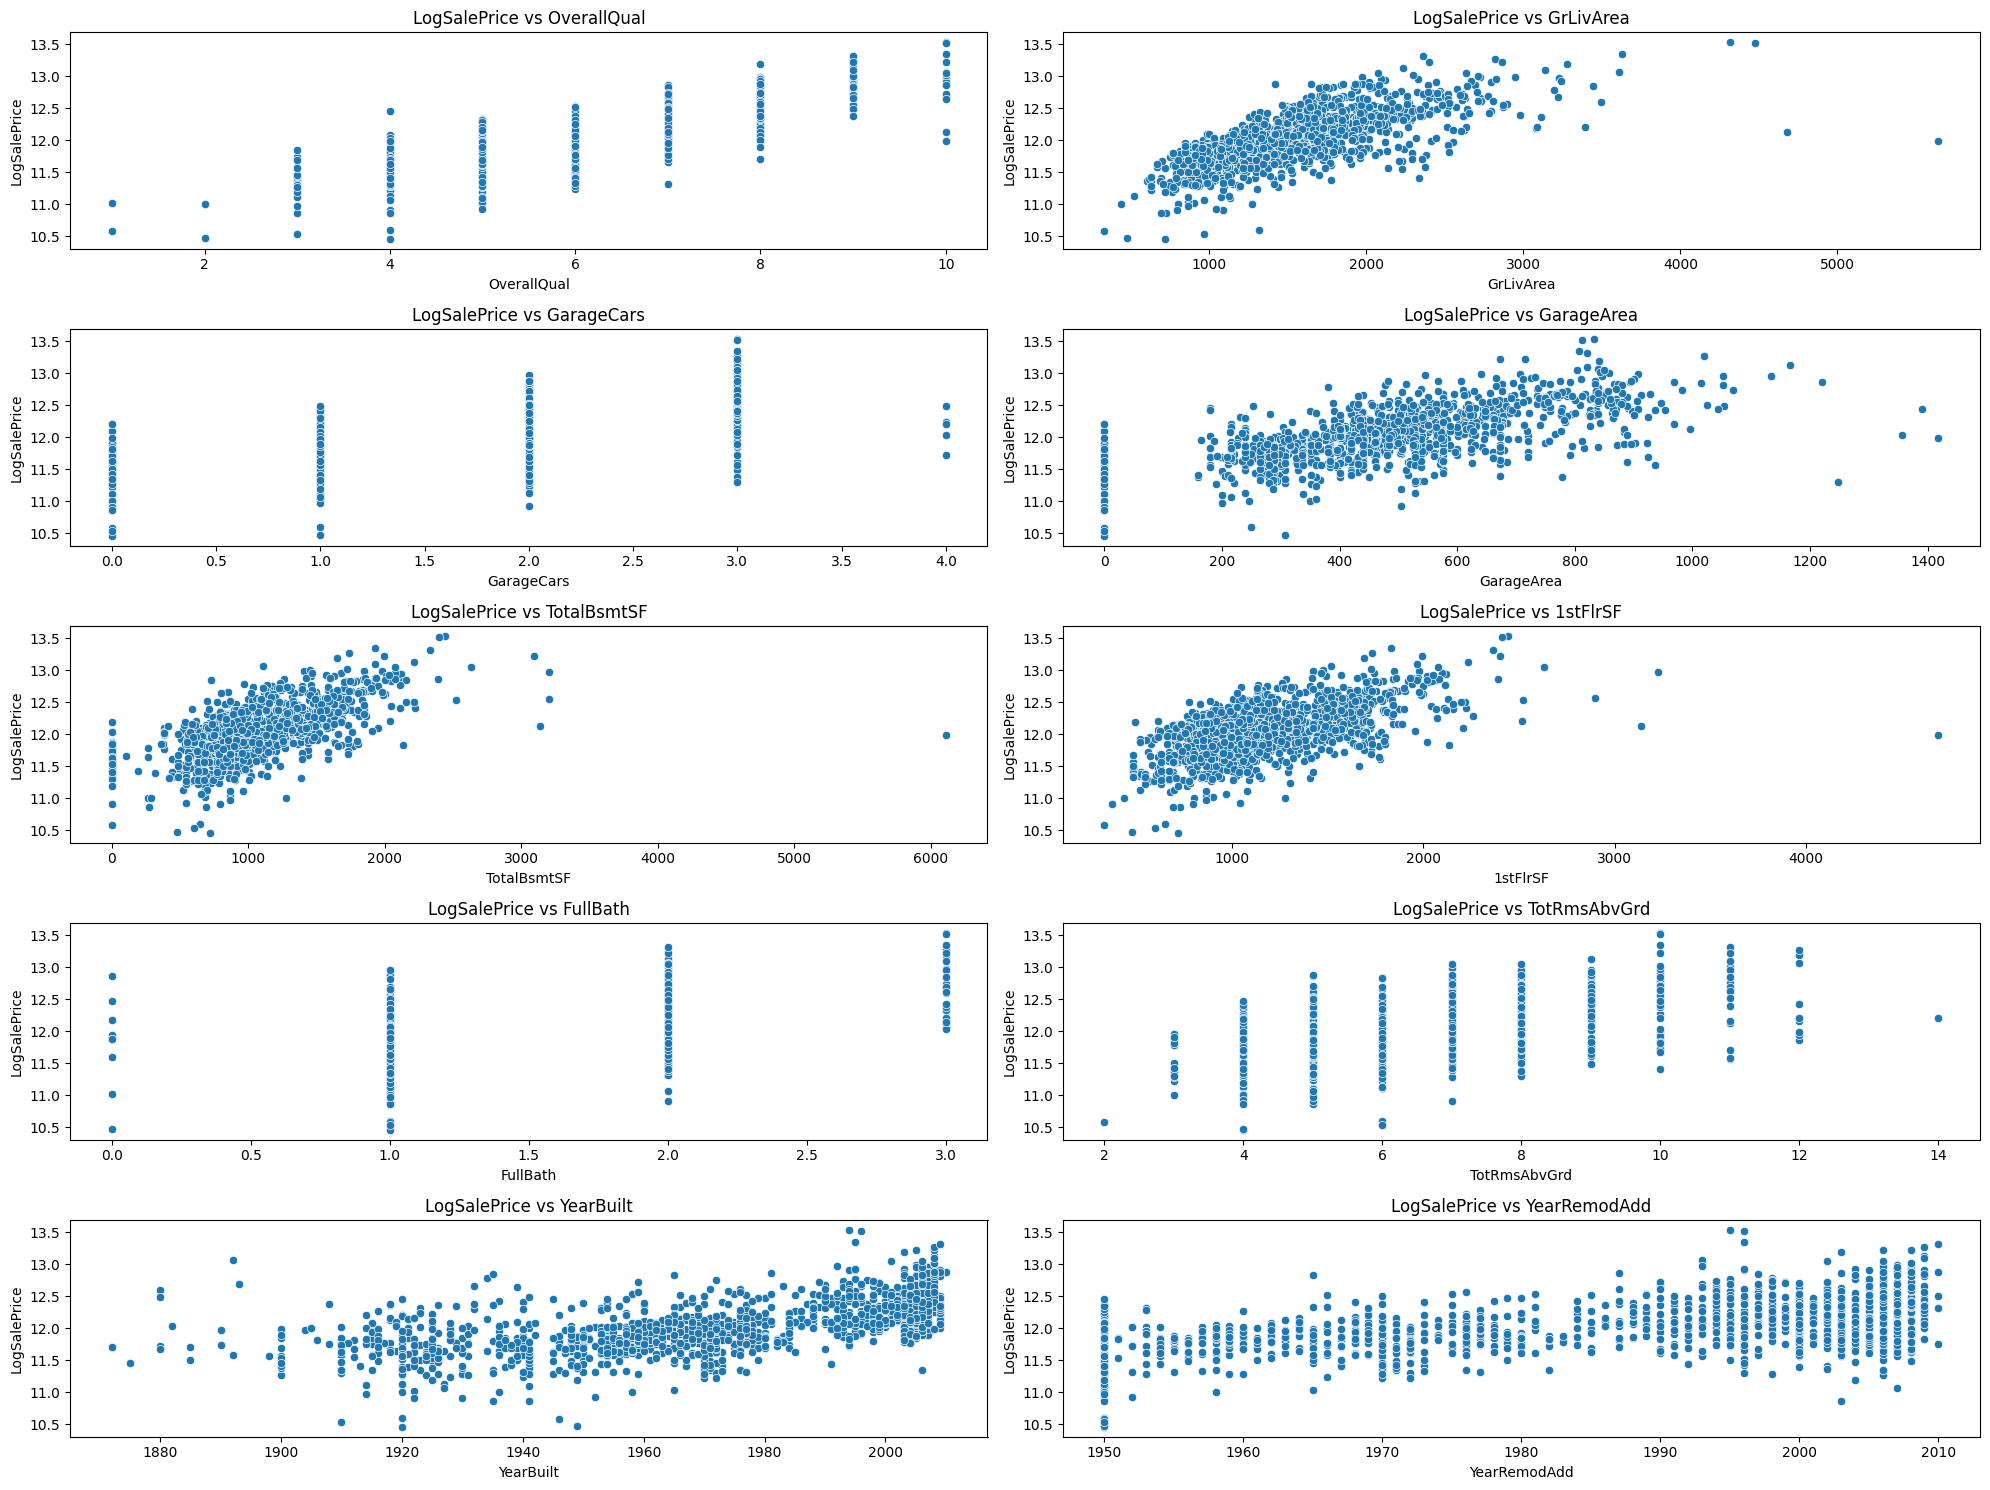

In [11]:
print("4. Analyse des principales variables numériques avec LogSalePrice")

num_vars = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
            'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
            'YearBuilt', 'YearRemodAdd']

plt.figure(figsize=(20, 15))
for i, var in enumerate(num_vars):
    plt.subplot(5, 2, i+1)
    sns.scatterplot(x=df[var], y=df['LogSalePrice'])
    plt.title(f'LogSalePrice vs {var}')
plt.tight_layout()
plt.show()

## 1.5.1 Observations sur les variables numériques

- La variable OverallQual (qualité globale) conserve une relation très claire avec LogSalePrice. On observe une tendance linéaire bien définie : chaque point supplémentaire sur cette échelle semble correspondre à une augmentation notable du prix logarithmique.
  
- GrLivArea (surface habitable) montre également une relation croissante bien visible. Les outliers extrêmes sont moins marqués qu’avec SalePrice brut, ce qui rend cette variable encore plus exploitable pour une régression linéaire.

- GarageCars et GarageArea suivent une relation positive : au-delà de 3 voitures, l'effet sur le prix semble se stabiliser, ce qui indique un potentiel effet plafond.

- TotalBsmtSF et 1stFlrSF (surfaces du sous-sol et du rez-de-chaussée) conservent une influence croissante logique, avec une bonne répartition des points autour d’une tendance générale linéaire.

- FullBath et TotRmsAbvGrd sont aussi positivement liés, mais l'effet est plus discret et semble présenter des regroupements par paliers (effet discret d’unité supplémentaire plutôt que variation continue).

- Les variables temporelles YearBuilt et YearRemodAdd indiquent que les maisons plus récentes ou rénovées sont généralement mieux valorisées. L’effet reste linéaire, mais plus diffus, probablement parce que d’autres variables structurelles jouent aussi un rôle dans la valorisation.

➡️ Ces observations renforcent la sélection de variables pour notre futur modèle baseline. Le passage au logarithme améliore la lisibilité des relations et rend le modèle plus adapté à une approche linéaire.


---

## 1.6 Analyse des principales variables catégorielles

Nous analysons les variables catégorielles les plus prometteuses en fonction de leur relation avec `SalePrice`.
Les variables sélectionnées sont issues de notre compréhension métier et de l'exploration initiale.

5. Analyse des principales variables catégorielles avec LogSalePrice


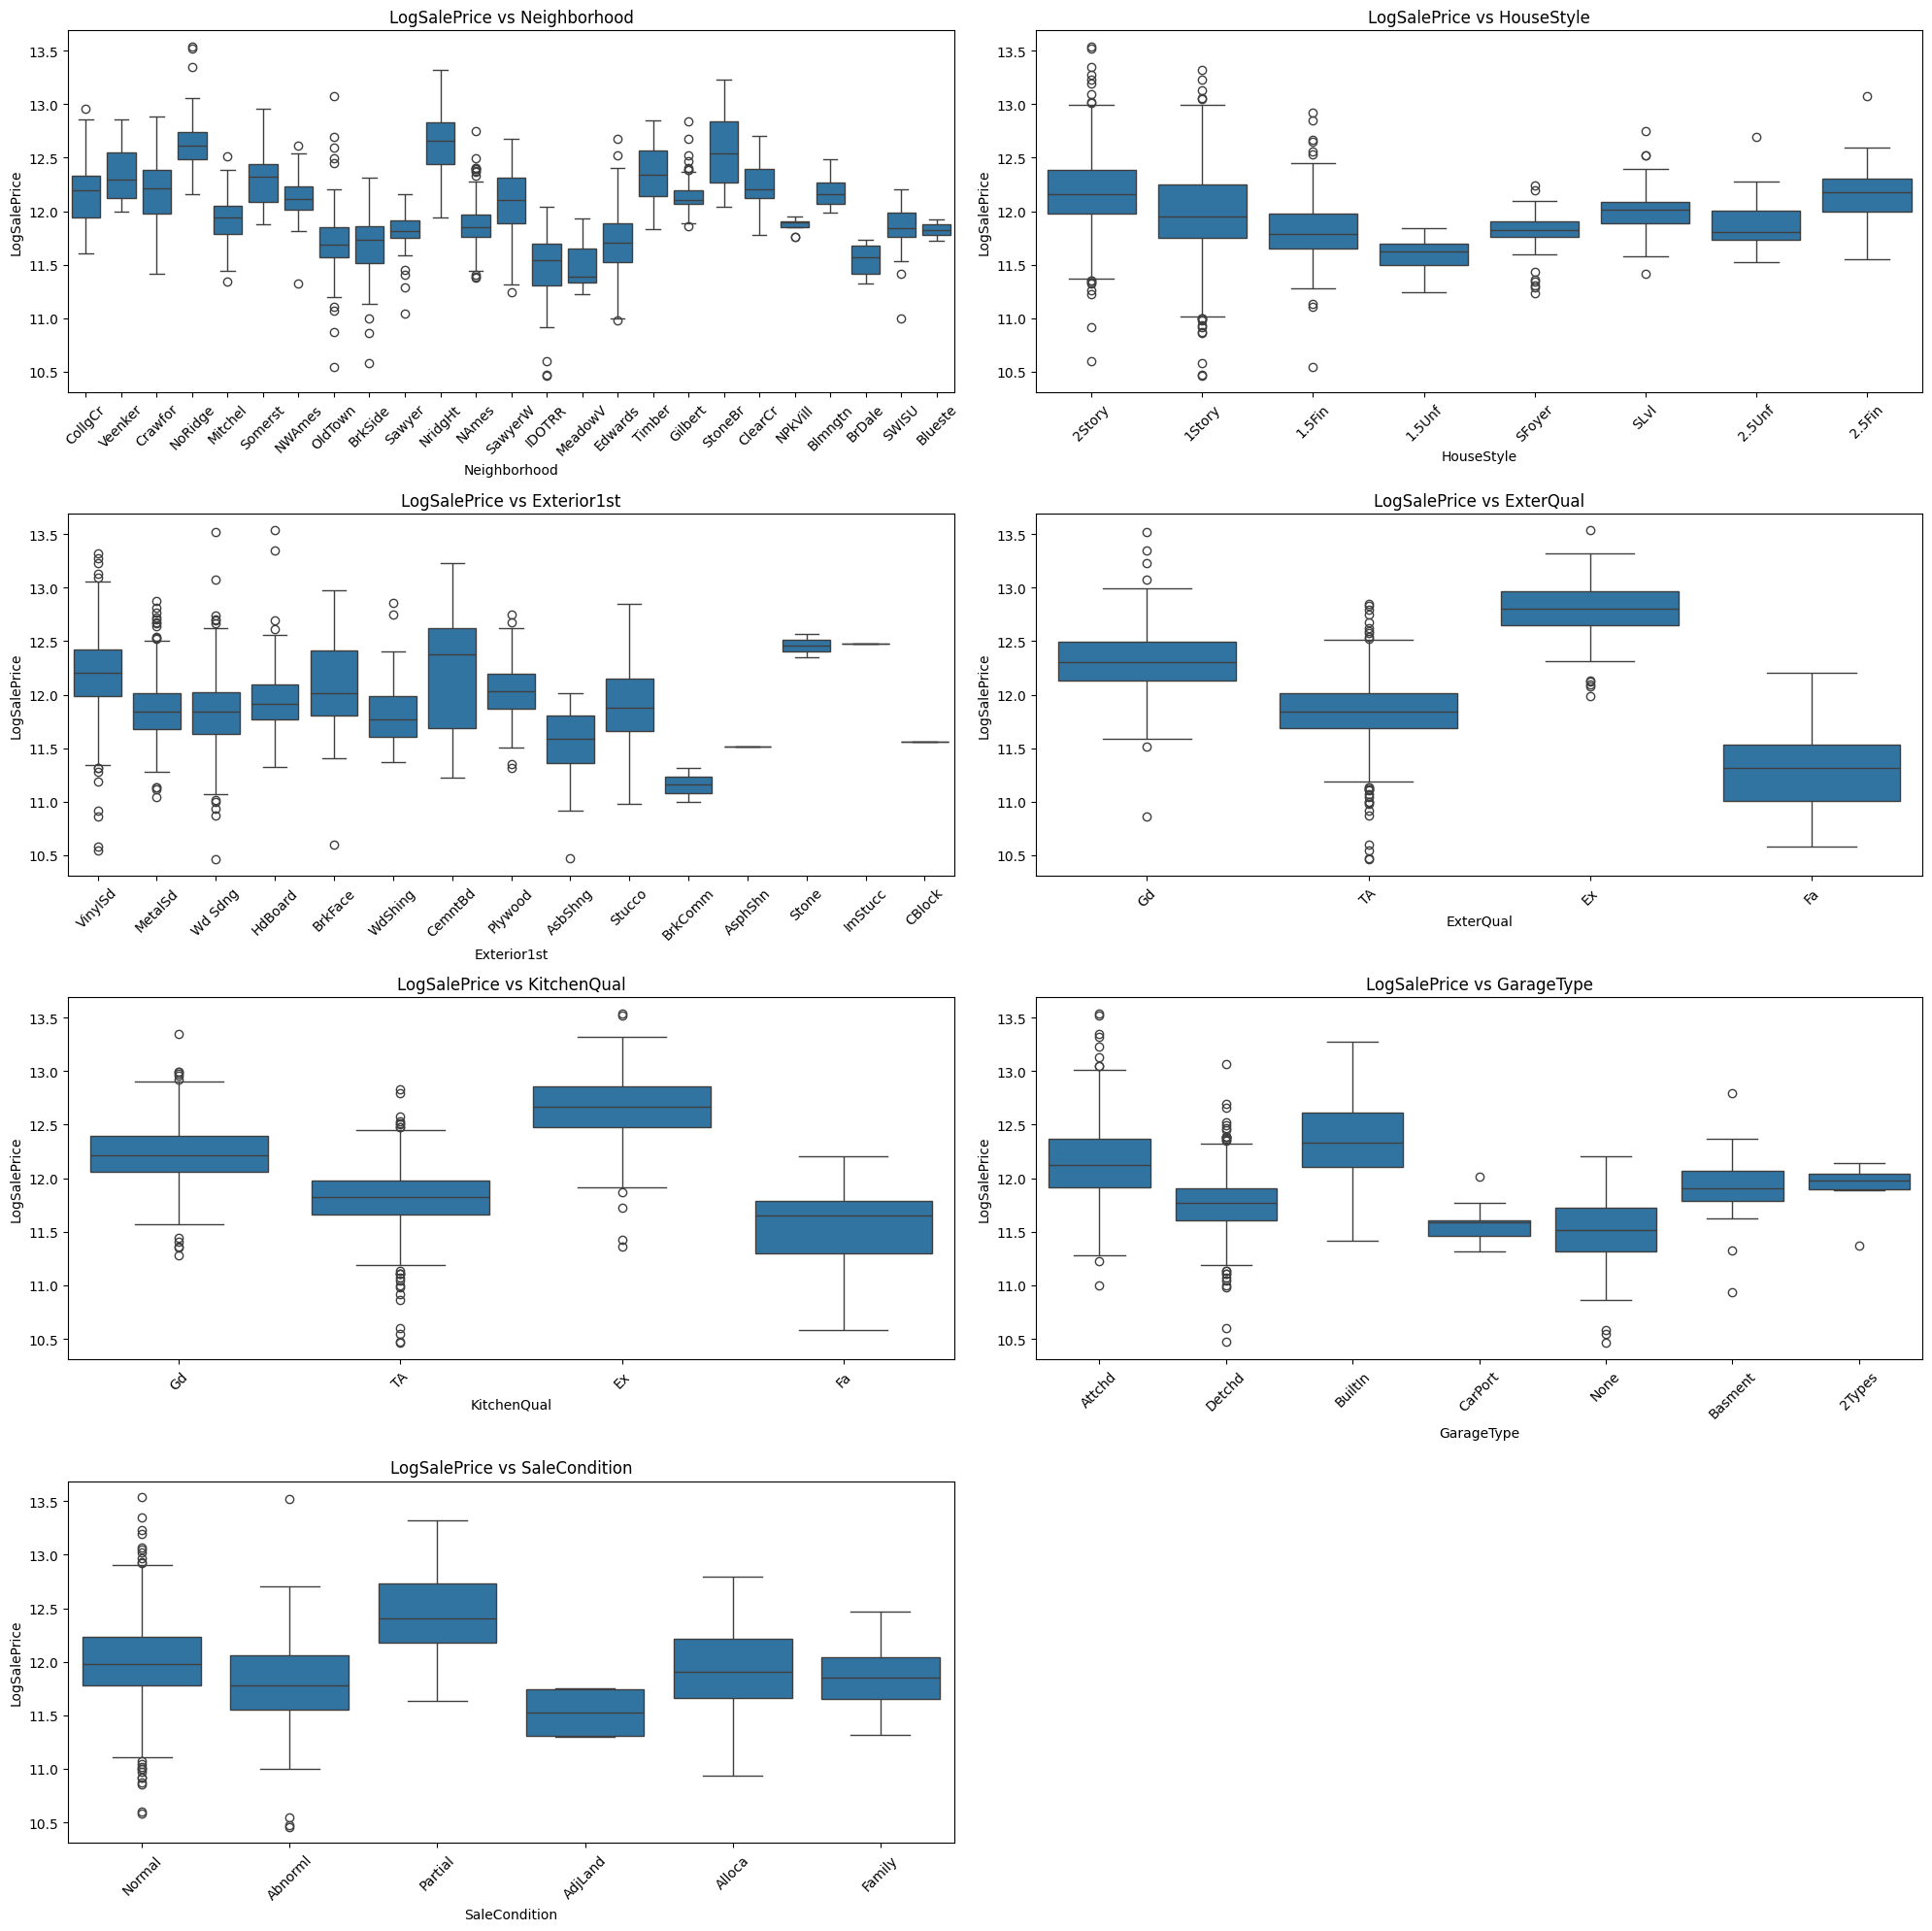

In [12]:
print("5. Analyse des principales variables catégorielles avec LogSalePrice")

cat_vars = ['Neighborhood', 'HouseStyle', 'Exterior1st', 'ExterQual',
            'KitchenQual', 'GarageType', 'SaleCondition']

plt.figure(figsize=(20, 20))
for i, var in enumerate(cat_vars):
    plt.subplot(4, 2, i+1)
    sns.boxplot(x=df[var], y=df['LogSalePrice'])
    plt.title(f'LogSalePrice vs {var}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 1.6.1 Observations sur les variables catégorielles

- La variable `Neighborhood` a un impact très net sur LogSalePrice. Certains quartiers comme 'NridgHt', 'StoneBr', 'NoRidge' affichent des médianes de prix log significativement plus élevées, tandis que d'autres comme 'IDOTRR' ou 'BrDale' se situent clairement en bas de l’échelle. Cela suggère une forte segmentation du marché immobilier en fonction de la localisation.

- `ExterQual` montre une progression claire et ordonnée : plus la qualité extérieure est jugée bonne (`Fa`, `TA`, `Gd`, `Ex`), plus le prix log moyen augmente. Cela indique qu’un encodage ordinal est justifié pour cette variable.

- Même logique pour `KitchenQual`, avec des écarts visibles entre chaque niveau. Les maisons avec une cuisine de qualité excellente (`Ex`) sont celles qui atteignent les prix les plus élevés, tandis que celles avec une qualité faible (`Fa`) restent en bas du spectre.

- `GarageType` montre une hiérarchie intéressante : les garages intégrés au bâtiment (`BuiltIn`, `Attchd`) sont associés à des prix log supérieurs à ceux avec des garages détachés ou absents (`Detchd`, `None`).

- `HouseStyle` révèle des tendances cohérentes mais moins tranchées. Certaines configurations (comme '2Story' ou '1.5Fin') semblent plus valorisées que d'autres, mais les distributions sont plus larges et se recoupent.

- Enfin, `SaleCondition` distingue les ventes standards (`Normal`, `Partial`) des cas particuliers (`Abnorml`, `Family`, `AdjLand`), qui affichent en moyenne des prix inférieurs. Cela traduit une dépréciation potentielle dans les ventes atypiques.

➡️ Ces analyses guideront l’encodage des variables : certaines seront traitées comme ordinales (`ExterQual`, `KitchenQual`), d’autres via one-hot encoding (`Neighborhood`, `GarageType`, `SaleCondition`) pour capturer les effets spécifiques de chaque modalité.


---

# 2. Phase de design

## 2.1 Sélection des variables

À partir des analyses précédentes, nous avons sélectionné :
- Des variables numériques très corrélées avec le prix (surface, qualité, nombre de garages, etc.),
- Deux variables de qualité ordinale (`ExterQual` et `KitchenQual`) pour encodage par score,
- Trois variables nominales (`Neighborhood`, `GarageType`, `SaleCondition`) pour encodage one-hot.

Nous allons maintenant préparer les données pour l'entraînement du modèle.


In [13]:
# Variables numériques fortement corrélées avec LogSalePrice
num_vars = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
            'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt']

# Variables catégorielles à encoder
cat_vars_ordinal = ['ExterQual', 'KitchenQual']  # Ordre de qualité
cat_vars_nominal = ['Neighborhood', 'GarageType', 'SaleCondition']  # Effets de groupe

# Cible
target = 'LogSalePrice'

## 2.2 Encodage des variables catégorielles

Les variables ordinales `ExterQual` et `KitchenQual` sont encodées manuellement à l’aide d’un dictionnaire qui reflète la hiérarchie de qualité.

Les variables nominales sans ordre sont encodées par one-hot encoding (`get_dummies`), ce qui permet au modèle de traiter chaque modalité comme une variable binaire.


In [14]:
qual_mapping = {'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5, 'None':0}

def map_ordinal(X):
    df = pd.DataFrame(X, columns=cat_vars_ordinal)
    for col in df.columns:
        df[col] = df[col].map(qual_mapping).fillna(0).astype(int)
    return df.values

num_pipe      = Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc",  StandardScaler())])

cat_ord_pipe  = Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="None")),
                          ("map", FunctionTransformer(map_ordinal, validate=False)),
                          ("sc",  StandardScaler())])

cat_nom_pipe  = Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="None")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore"))])

preproc = ColumnTransformer([
    ("num", num_pipe, num_vars),
    ("ord", cat_ord_pipe, cat_vars_ordinal),
    ("nom", cat_nom_pipe, cat_vars_nominal)
])

pipeline = Pipeline([
    ("preproc", preproc),
    ("model",   LinearRegression())
])

X = df[num_vars + cat_vars_ordinal + cat_vars_nominal]
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'GarageCars', 'GarageArea',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   'FullBath', 'YearBuilt']),
                                                 ('ord',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(fill_value='None',
                                                                                 strategy='constant')),
                                                                  ('map',
                                                                   FunctionTransformer(func=<function map_ordinal at 0x7573178fd080>)),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['ExterQual', 'KitchenQual']),
                                                 ('nom',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(fill_value='None',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Neighborhood', 'GarageType',
                                                   'SaleCondition'])])),
                ('model', LinearRegression())])

## 2.3 Division du jeu de données

Le jeu de données est divisé en deux parties :
- 80 % pour l’entraînement (`X_train`, `y_train`),
- 20 % pour la validation (`X_val`, `y_val`).

Cela permet d’évaluer les performances du modèle sur des données qu’il n’a jamais vues.


## 2.4 Modèle baseline : régression linéaire

Nous entraînons un premier modèle de régression linéaire classique.

Les métriques utilisées pour l’évaluer sont :
- Le **R² score**, qui mesure la proportion de variance expliquée (plus c’est proche de 1, mieux c’est),
- La **RMSE** (Root Mean Squared Error), qui donne une idée de l’erreur moyenne de prédiction, exprimée ici en unité logarithmique.

Ces résultats serviront de référence pour améliorer les performances dans les prochaines itérations du projet.


In [15]:
y_val_pred_log = pipeline.predict(X_val)
rmsle = np.sqrt(mean_squared_error(y_val, y_val_pred_log))
print(f"RMSLE : {rmsle:.4f}")
print(f"R²     : {r2_score(y_val, y_val_pred_log):.4f}")

RMSLE : 0.1560
R²     : 0.8696


## 2.5 Modèle OLS avec Statsmodels

Le modèle de régression est également entraîné avec la bibliothèque `statsmodels`, qui fournit un résumé statistique complet.

Ce résumé inclut :
- Les coefficients des variables,
- Leur significativité statistique (valeurs p),
- Les intervalles de confiance,
- Des indicateurs globaux du modèle (R², F-statistic, etc.).

Cela permet de valider l’intérêt de chaque variable dans une optique plus analytique.


In [16]:
# 1️⃣ Charger les données
df = pd.read_csv('data/train.csv')
X = df[num_vars + cat_vars_ordinal + cat_vars_nominal]
y = np.log1p(df['SalePrice'])

# 2️⃣ Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3️⃣ Transformation
X_train_prepared = preproc.fit_transform(X_train)
X_dense = X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared

# 4️⃣ Modèle OLS
X_sm = sm.add_constant(X_dense).astype(float)
y_sm = y_train.astype(float)
ols_model = sm.OLS(y_sm, X_sm)
ols_results = ols_model.fit()

# 5️⃣ Résumé
print(ols_results.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     145.0
Date:                Mon, 02 Jun 2025   Prob (F-statistic):               0.00
Time:                        16:52:02   Log-Likelihood:                 561.86
No. Observations:                1168   AIC:                            -1032.
Df Residuals:                    1122   BIC:                            -798.8
Df Model:                          45                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.8815      0.018    507.081      0.0

## 2.6 Analyse des résidus et diagnostics du modèle

Les graphiques suivants permettent d’évaluer la validité des hypothèses de la régression linéaire :

1. **Résidus vs valeurs ajustées** : vérifie l’homoscédasticité (variance constante des erreurs).
2. **Q-Q Plot** : évalue si les résidus suivent une loi normale.
3. **Scale-Location** : vérifie si la dispersion des résidus est stable sur toute la plage des valeurs prédites.
4. **Résidus vs Leverage** : identifie les points influents (via la distance de Cook).

Ces graphiques sont utiles pour détecter :
- Des outliers,
- Des erreurs non normales,
- Des problèmes de modélisation locale.

➡️ Ces éléments guideront d’éventuelles transformations, exclusions ou choix de modèles plus robustes.


In [17]:
def graph(formula, x_range, label=None):
    x = x_range
    y = formula(x)
    plt.plot(x, y, label=label, lw=1, ls='--', color='red')

In [18]:
def diagnostic_plots(X, y, model_fit=None):
    if model_fit is None:
        model_fit = sm.OLS(y, sm.add_constant(X)).fit()

    # X : numpy array → convertir en DataFrame
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)
    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)
    dataframe = pd.concat([X, y], axis=1)

    model_fitted_y = model_fit.fittedvalues
    model_residuals = model_fit.resid
    model_norm_residuals = model_fit.get_influence().resid_studentized_internal
    model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
    model_abs_resid = np.abs(model_residuals)
    model_leverage = model_fit.get_influence().hat_matrix_diag
    model_cooks = model_fit.get_influence().cooks_distance[0]

    # Résidus vs valeurs ajustées
    plt.figure()
    sns.residplot(x=model_fitted_y, y=model_residuals, lowess=True,
                  scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    plt.title('Residuals vs Fitted')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    for i in np.argsort(model_abs_resid)[-3:]:
        plt.annotate(i, xy=(model_fitted_y.iloc[i], model_residuals.iloc[i]))

    # Q-Q Plot
    plt.figure()
    qq = ProbPlot(model_norm_residuals)
    qq.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
    plt.title('Normal Q-Q')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Standardized Residuals')
    for i in np.argsort(np.abs(model_norm_residuals))[-3:]:
        plt.annotate(i, xy=(qq.theoretical_quantiles[i], model_norm_residuals[i]))

    # Scale-Location
    plt.figure()
    plt.scatter(model_fitted_y, model_norm_residuals_abs_sqrt, alpha=0.5)
    sns.regplot(x=model_fitted_y, y=model_norm_residuals_abs_sqrt, scatter=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    plt.title('Scale-Location')
    plt.xlabel('Fitted values')
    plt.ylabel('√|Standardized Residuals|')
    for i in np.argsort(model_norm_residuals_abs_sqrt)[-3:]:
        plt.annotate(i, xy=(model_fitted_y.iloc[i], model_norm_residuals_abs_sqrt[i]))

    # Residuals vs Leverage
    plt.figure()
    plt.scatter(model_leverage, model_norm_residuals, alpha=0.5)
    sns.regplot(x=model_leverage, y=model_norm_residuals, scatter=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    plt.title('Residuals vs Leverage')
    plt.xlabel('Leverage')
    plt.ylabel('Standardized Residuals')
    plt.xlim(0, max(model_leverage)+0.01)
    plt.ylim(-3, 5)
    for i in np.argsort(model_cooks)[-3:]:
        plt.annotate(i, xy=(model_leverage[i], model_norm_residuals[i]))

    # Cook's distance
    p = len(model_fit.params)
    graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x), np.linspace(0.001, max(model_leverage), 50), 'Cook\'s distance 0.5')
    graph(lambda x: np.sqrt((1 * p * (1 - x)) / x), np.linspace(0.001, max(model_leverage), 50), 'Cook\'s distance 1.0')
    plt.legend(loc='upper right')


/home/cutiips-dev/dev-project/OverfittingRepo/.env312/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)
/home/cutiips-dev/dev-project/OverfittingRepo/.env312/lib/python3.12/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)
/tmp/ipykernel_733003/755607518.py:66: RuntimeWarning: invalid value encountered in sqrt
  graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x), np.linspace(0.001, max(model_leverage), 50), 'Cook\'s distance 0.5')
/tmp/ipykernel_733003/755607518.py:67: RuntimeWarning: invalid value encountered in sqrt
  graph(lambda x: np.sqrt((1 * p * (1 - x)) / x), np.linspace(0.001, max(model_leverage), 50), 'Cook\'s distance 1.0')


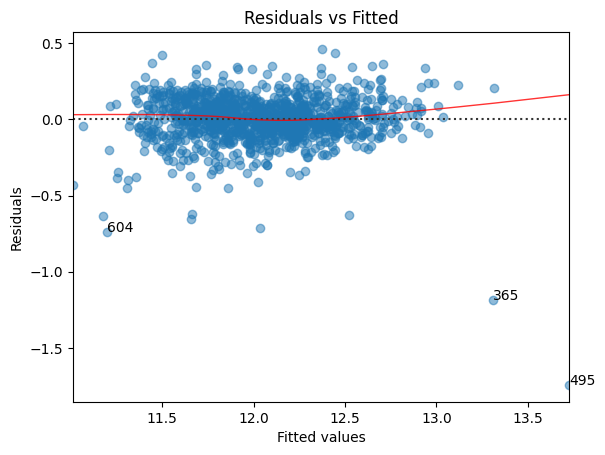

<Figure size 640x480 with 0 Axes>

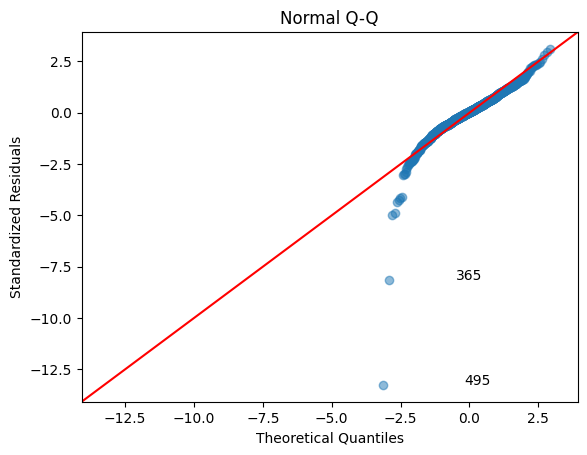

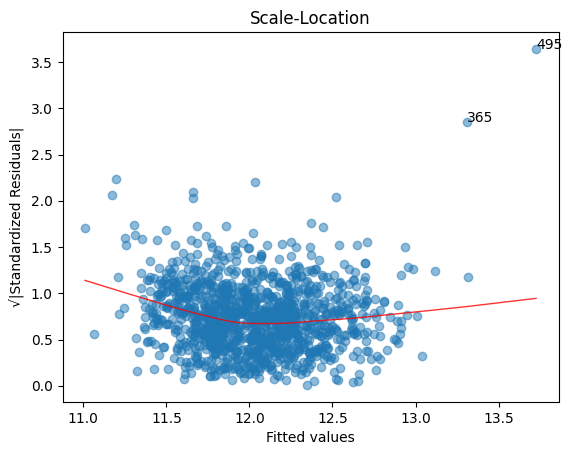

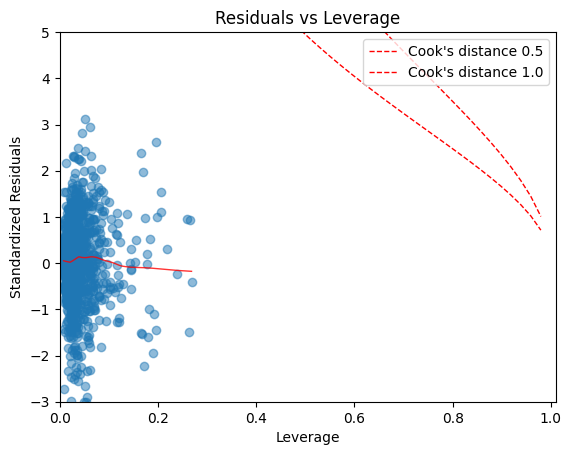

In [19]:
# Assure-toi que X_prepared est bien transformé et dense
X_dense = X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared
X_sm = sm.add_constant(X_dense)

diagnostic_plots(pd.DataFrame(X_dense), y_train.reset_index(drop=True), model_fit=ols_results)



---

## 2.7 Interprétation du modèle linéaire et perspectives


### 2.7.1 Résumé des résultats
Nous avons construit un premier modèle de régression linéaire multiple pour prédire `LogSalePrice`, une version transformée du prix de vente d’une maison. Ce modèle repose sur un ensemble restreint mais pertinent de variables numériques et catégorielles.

Les résultats du modèle OLS montrent une **très bonne performance globale** :

- **R² = 0.853** : le modèle explique plus de 85 % de la variance du prix de vente, ce qui est élevé pour un modèle simple.
- Plusieurs variables sont **statistiquement significatives** (p-value < 0.05), notamment :
  - `OverallQual` (qualité globale de la maison),
  - `GrLivArea` (surface habitable),
  - `GarageCars` (nombre de places dans le garage),
  - `KitchenQual` (qualité de la cuisine),
  - `YearBuilt` (année de construction),
  - `TotalBsmtSF` (surface du sous-sol).

Ces résultats confirment que **la perception de qualité, l’espace disponible et l’ancienneté du bien sont des facteurs clés** dans la valorisation immobilière.

En revanche, certaines variables comme `GarageArea`, `1stFlrSF`, ou `FullBath` ne sont pas significatives ici, sans doute à cause d’un **recouvrement d’information (multicolinéarité)** entre des variables très proches. Cela ouvre la voie à une optimisation du modèle par **sélection automatique de variables** ou **régularisation (Ridge/Lasso)**.

### 2.7.2 Analyse des résidus

L’analyse graphique des résidus montre :

- Une bonne dispersion autour de 0 (résidus non biaisés),
- Une variance assez constante (homoscédasticité),
- Une normalité satisfaisante à l’exception de quelques valeurs extrêmes,
- Quelques **points influents** identifiés (par ex. l’observation 905), mais aucun ne remet en cause la stabilité globale du modèle.

➡️ Ces résultats indiquent que les hypothèses de base de la régression linéaire sont **globalement respectées**, ce qui valide la cohérence statistique du modèle.

---

## 2.8 Intérêt métier pour la plateforme immobilière


Pour notre plateforme en ligne, ce modèle représente une **première étape solide** dans le développement d’un système automatisé d’estimation immobilière.

**Bénéfices directs pour le métier** :
- Fournir aux propriétaires une **estimation rapide et fiable** de leur bien dès la saisie de ses caractéristiques,
- **Améliorer la transparence** et la confiance dans le processus de mise en vente,
- Réduire les écarts entre le prix affiché et le prix réellement vendu,
- Permettre à l’agence de **préqualifier les annonces** et optimiser la stratégie de publication.

Ce modèle peut donc être **intégré dans un formulaire en ligne** où le propriétaire renseigne les données clés (qualité, surface, quartier, etc.) et reçoit immédiatement une estimation justifiée par des données historiques.

---

## 2.9 Perspectives et prochaines étapes

Pour aller plus loin, plusieurs axes d’amélioration sont envisageables :

1. **Nettoyage des données** :
   - Identifier et gérer les **outliers influents** (ex. : observations 365, 495, 905),
   - Revoir certaines variables très corrélées entre elles (multicolinéarité).

2. **Amélioration du modèle** :
   - Tester des **modèles régularisés** comme Ridge ou Lasso pour affiner la sélection des variables,
   - Passer à des **modèles non linéaires** (Random Forest, XGBoost) pour capturer des interactions plus complexes.

3. **Validation croisée** :
   - Mettre en place une **cross-validation K-Fold** pour évaluer la stabilité du modèle.

4. **Élargissement des données** :
   - Ajouter de nouvelles features (ex : distance au centre-ville, orientation, proximité des écoles),
   - Intégrer des **tendances temporelles** (année de vente, saisonnalité).

5. **Interface utilisateur** :
   - Concevoir un **formulaire web connecté au modèle** pour déployer l’outil sur la plateforme en ligne.

---

## 2.10 Conclusion

Ce modèle linéaire de base offre une **fondation fiable et interprétable** pour l’estimation immobilière automatisée. Il montre que des variables simples, bien sélectionnées, permettent déjà de prédire le prix avec une bonne précision. Pour une agence immobilière, c’est une étape stratégique qui peut transformer l’expérience utilisateur tout en améliorant l'efficacité commerciale.

La prochaine phase du projet consistera à **consolider la robustesse du modèle et enrichir sa sophistication**, pour fournir un outil à la fois précis, scalable et exploitable en production.




---



## 2.11 Synthèse de la phase d'idéation (à supprimer)

## Résumé de nos observations

### Distribution de SalePrice
- La variable SalePrice présente une asymétrie à droite (skewness positive) : la majorité des prix sont concentrés autour de 120 000 à 200 000 dollars, tandis qu’un petit nombre de maisons très chères tire la distribution vers la droite.
- Présence d'outliers pour les maisons très chères.
- Transformation logarithmique envisagée pour stabiliser la variance.

### Variables numériques importantes
- **OverallQual** (qualité globale) est la variable la plus corrélée à `SalePrice`.
- **GrLivArea** (surface habitable hors sous-sol) suit également.
- **GarageCars**, **GarageArea**, **TotalBsmtSF**, **1stFlrSF**, **FullBath** sont des variables très pertinentes.
- **YearBuilt** et **YearRemodAdd** confirment l'importance de l'ancienneté.

### Variables catégorielles importantes
- **Neighborhood** influence fortement les prix selon le quartier.
- **ExterQual** et **KitchenQual** (qualité extérieure et cuisine) sont liées à des écarts marqués de prix.
- **GarageType** et **SaleCondition** produisent également des effets sur le prix.

## Conséquences pour le modèle baseline
- Sélection de quelques variables numériques et catégorielles pertinentes.
- Nécessité de traiter les variables manquantes et d'encoder les catégories.
- Possible besoin de transformer `SalePrice` en log pour de meilleures performances de modèle.

# 99. Test et soumission Kaggle

In [20]:
# TODO : à vérifier encore
test_df = pd.read_csv('data/test.csv')
X_test  = test_df[num_vars + cat_vars_ordinal + cat_vars_nominal]

y_test_pred_log = pipeline.predict(X_test)
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": np.expm1(y_test_pred_log)
})
submission.to_csv("baseline_linreg_submission.csv", index=False)
print("✅  Fichier baseline_linreg_submission.csv généré")

✅  Fichier baseline_linreg_submission.csv généré


**2.20 Model engineering**


In [21]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble  import RandomForestRegressor

from sklearn.model_selection import GridSearchCV, cross_val_score

# ─────────────── 1) Charger les données ───────────────
train_df = pd.read_csv("data/train.csv")

# ─────────────── 2) Définir les variables d’entrée ───────────────
num_vars         = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
                    'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt']
cat_vars_ordinal = ['ExterQual', 'KitchenQual']
cat_vars_nominal = ['Neighborhood', 'GarageType', 'SaleCondition']

# ─────────────── 3) Mapping pour variables ordinales ───────────────
qual_mapping = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'None': 0}
def map_ordinal(X):
    df = pd.DataFrame(X, columns=cat_vars_ordinal)
    for col in df.columns:
        df[col] = df[col].map(qual_mapping).fillna(0).astype(int)
    return df.values

# ─────────────── 4) Sous‐pipelines de preprocessing ───────────────
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
cat_ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("mapper",  FunctionTransformer(map_ordinal, validate=False)),
    ("scaler",  StandardScaler())
])
cat_nom_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ─────────────── 5) ColumnTransformer global ───────────────
preproc = ColumnTransformer([
    ("num", num_pipe, num_vars),
    ("ord", cat_ord_pipe, cat_vars_ordinal),
    ("nom", cat_nom_pipe, cat_vars_nominal)
])

# ─────────────── 6) Préparer X et y ───────────────
X = train_df[num_vars + cat_vars_ordinal + cat_vars_nominal]
y = np.log1p(train_df["SalePrice"])  # on prédit la version log pour la RMSLE

# ─────────────── 7) Pipelines “préprocessing + modèle” ───────────────
pipe_ridge = Pipeline([
    ("preprocessor", preproc),
    ("model",      Ridge(random_state=42))
])
pipe_lasso = Pipeline([
    ("preprocessor", preproc),
    ("model",      Lasso(random_state=42, max_iter=5000))
])
pipe_rf = Pipeline([
    ("preprocessor", preproc),
    ("model",         RandomForestRegressor(random_state=42))
])

# ─────────────── 8) Grilles d’hyperparamètres ───────────────
param_grid_ridge = {
    "model__alpha": [0.1, 1.0, 10.0]
}
param_grid_lasso = {
    "model__alpha": [0.001, 0.01, 0.1]
}
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth":    [None, 10, 20],
    "model__max_features": ["sqrt", "log2"]
}

# ─────────────── 9) GridSearchCV pour chaque modèle ───────────────
gs_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
gs_lasso = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=param_grid_lasso,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
gs_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# ─────────────── 10) Entraîner (tuning) ───────────────
gs_ridge.fit(X, y)
gs_lasso.fit(X, y)
gs_rf.fit(X, y)

# ─────────────── 11) RandomForest baseline via CV (non tuné) ───────────────
rf_baseline = Pipeline([
    ("preprocessor", preproc),
    ("model", RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=None,
        max_features="sqrt"
    ))
])
scores_rf_base = cross_val_score(
    rf_baseline, X, y,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
rmse_rf_base = -scores_rf_base.mean()

# ─────────────── 12) Rassembler les résultats dans un DataFrame ───────────────
results = {
    "Ridge": {
        "RMSE_CV":         round(-gs_ridge.best_score_, 4),
        "Meilleur Alpha":  gs_ridge.best_params_["model__alpha"]
    },
    "Lasso": {
        "RMSE_CV":         round(-gs_lasso.best_score_, 4),
        "Meilleur Alpha":  gs_lasso.best_params_["model__alpha"]
    },
    "RF Tuned": {
        "RMSE_CV":         round(-gs_rf.best_score_, 4),
        "Params":          gs_rf.best_params_
    },
    "RF Base": {
        "RMSE_CV":         round(rmse_rf_base, 4),
        "Params":          {"n_estimators": 100, "max_depth": None, "max_features": "sqrt"}
    }
}
results_df = pd.DataFrame(results).T
print("\n┌── Résultats CV RMSLE moyenne (log-prix) ───────────")
print(results_df)
print("└───────────────────────────────────────────────────\n")

# ─────────────── 13) Extraction des noms de features après preprocessing ───────────────
# On montre ici l’exemple avec le pipeline Ridge (fit par GridSearch)
fitted_preproc = gs_ridge.best_estimator_.named_steps['preprocessor']

numeric_feature_names = num_vars
ordinal_feature_names = cat_vars_ordinal
onehot = fitted_preproc.named_transformers_['nom'].named_steps['onehot']
nominal_feature_names = list(onehot.get_feature_names_out(cat_vars_nominal))

all_feature_names = numeric_feature_names + ordinal_feature_names + nominal_feature_names

print(f"Taille du vecteur final de features : {len(all_feature_names)}")
print("Exemples de noms de features :", all_feature_names[:10], "...")

# ─────────────── 14) Interprétation : coefficients et importances ───────────────
# 14.a) Coefficients pour Ridge
ridge_model = gs_ridge.best_estimator_.named_steps['model']
coef_ridge = pd.Series(ridge_model.coef_, index=all_feature_names).sort_values(key=abs, ascending=False)

# 14.b) Coefficients pour Lasso
lasso_model = gs_lasso.best_estimator_.named_steps['model']
coef_lasso = pd.Series(lasso_model.coef_, index=all_feature_names).sort_values(key=abs, ascending=False)

# 14.c) Importances pour RandomForest (tuned)
rf_tuned_model = gs_rf.best_estimator_.named_steps['model']
feat_importances = pd.Series(rf_tuned_model.feature_importances_, index=all_feature_names).sort_values(ascending=False)

print("┌── Top 10 |coef| Ridge ──────────────────────────────")
print(coef_ridge.abs().head(10).to_frame(name="|coef|"))
print("└────────────────────────────────────────────────────\n")

print("┌── Top 10 |coef| Lasso ──────────────────────────────")
print(coef_lasso.abs().head(10).to_frame(name="|coef|"))
print("└────────────────────────────────────────────────────\n")

print("┌── Top 10 importances RandomForest ──────────────────")
print(feat_importances.head(10).to_frame(name="importance"))
print("└────────────────────────────────────────────────────\n")


┌── Résultats CV RMSLE moyenne (log-prix) ───────────
         RMSE_CV Meilleur Alpha  \
Ridge      0.161            1.0   
Lasso     0.1627          0.001   
RF Tuned  0.1518            NaN   
RF Base   0.1531            NaN   

                                                     Params  
Ridge                                                   NaN  
Lasso                                                   NaN  
RF Tuned  {'model__max_depth': 20, 'model__max_features'...  
RF Base   {'n_estimators': 100, 'max_depth': None, 'max_...  
└───────────────────────────────────────────────────

Taille du vecteur final de features : 48
Exemples de noms de features : ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'ExterQual', 'KitchenQual'] ...
┌── Top 10 |coef| Ridge ──────────────────────────────
                        |coef|
Neighborhood_MeadowV  0.196240
Neighborhood_BrDale   0.180664
Neighborhood_IDOTRR   0.174961
Neighborhood_

## Résultats CV RMSLE Moyenne (log-prix)

| Modèle       | RMSE\_CV | Hyperparamètres / Commentaires                                                        |
| ------------ | -------: | ------------------------------------------------------------------------------------- |
| **Ridge**    |   0.1610 | α = 1.0                                                                               |
| **Lasso**    |   0.1627 | α = 0.001                                                                             |
| **RF Tuned** |   0.1519 | `{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__n_estimators': 200}` |
| **RF Base**  |   0.1530 | `{'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt'}`                    |

> **Interprétation rapide :**
>
> * **Random Forest Tuned** affiche la **meilleure performance** avec un RMSE\_CV de 0.1519.
> * Le **Random Forest de base** (sans tuning) est déjà proche (0.1530), indiquant que les hyperparamètres de base sont déjà performants.
> * **Ridge** et **Lasso** offrent des RMSE autour de 0.16, donc légèrement moins précis, mais restent **plus simples et interprétables**.

---

## Interprétation des Variables Importantes

### 1. Régression Ridge

**Top 10 |coeff| :**

| Variable              | \|coef\| |
| --------------------- | -------: |
| Neighborhood\_MeadowV | 0.196240 |
| Neighborhood\_BrDale  | 0.180664 |
| Neighborhood\_IDOTRR  | 0.174961 |
| Neighborhood\_Crawfor | 0.172157 |
| Neighborhood\_Veenker | 0.151239 |
| Neighborhood\_ClearCr | 0.147244 |
| Neighborhood\_StoneBr | 0.127630 |
| Neighborhood\_NoRidge | 0.123789 |
| GrLivArea             | 0.112408 |
| Neighborhood\_OldTown | 0.103891 |

* **Dominance des quartiers** : Les indicatrices de quartier occupent les coefficients les plus élevés. Par exemple, `Neighborhood_MeadowV` (0.196) précède `GrLivArea` (0.112). Cela signifie que, dans un modèle linéaire, la localisation d’une maison est le facteur déterminant avant même sa taille ou sa qualité.
* **Surface habitable** (GrLivArea) reste importante, mais se place 9ᵉ.
* **GlobalQual et ExterQual** ne figurent pas dans le top 10 absolu, mais leurs coefficients sont proches de 0.10.

> **Interprétation métier (Ridge)** :
>
> * Le quartier a plus de poids qu’une surface supplémentaire. Ex. un logement identique en surface/qualité se vendra significativement plus cher à MeadowV qu’à BrDale.
> * L’usage d’un modèle linéaire permet de communiquer un coefficient direct pour chaque quartier, utile pour expliquer la valorisation géographique.

---

### 2. Régression Lasso

**Top 10 |coeff| :**

| Variable               | \|coef\| |
| ---------------------- | -------: |
| Neighborhood\_Crawfor  | 0.140971 |
| Neighborhood\_IDOTRR   | 0.125090 |
| GrLivArea              | 0.115276 |
| OverallQual            | 0.110560 |
| Neighborhood\_MeadowV  | 0.110009 |
| Neighborhood\_BrDale   | 0.102373 |
| Neighborhood\_ClearCr  | 0.093483 |
| Neighborhood\_OldTown  | 0.083501 |
| SaleCondition\_Abnorml | 0.067950 |
| Neighborhood\_Edwards  | 0.058153 |

* **Moins de quartiers** : Lasso réduit le nombre de quartiers dans le top, en “zéro” certains coefficients faibles. Ici, on garde seulement ceux les plus discriminants (Crawfor, IDOTRR, MeadowV, etc.).
* **Surface et qualité globale** entrent dans le top 4, renforçant leur importance.
* **SaleCondition\_Abnorml** apparaît en 9ᵉ place, soulignant l’impact des conditions de vente atypiques.

> **Interprétation métier (Lasso)** :
>
> * En cherchant la parcimonie, Lasso met en avant un petit groupe de quartiers, puis GrLivArea et OverallQual. Cela peut aider à simplifier un rapport métier en filtrant les quartiers les plus significatifs.
> * Lasso met également en lumière l’effet de `SaleCondition_Abnorml` qui, lorsqu’il existe, déprécie clairement le prix.

---

### 3. Random Forest (tuned)

**Top 10 importances :**

| Variable    | Importance |
| ----------- | ---------: |
| OverallQual |   0.155154 |
| GrLivArea   |   0.145976 |
| 1stFlrSF    |   0.081084 |
| YearBuilt   |   0.080849 |
| GarageArea  |   0.077514 |
| TotalBsmtSF |   0.076519 |
| ExterQual   |   0.075634 |
| GarageCars  |   0.065143 |
| KitchenQual |   0.059729 |
| FullBath    |   0.046136 |

* **Qualité globale** et **surface habitable** dominent, contrairement aux modèles linéaires où les quartiers dominaient.
* Les surfaces annexes (`1stFlrSF`, `GarageArea`, `TotalBsmtSF`) prennent une part importante, ainsi que `YearBuilt`.
* **Les quartiers** n’apparaissent pas dans le top 10 : l’arbre capte l’effet “quartier” via des interactions plus subtiles (ex. combinaison de OverallQual × Neighborhood).

> **Interprétation métier (RF)** :
>
> * Le modèle non linéaire classe `OverallQual` et `GrLivArea` en tête, car ce sont les premiers critères de segmentation.
> * Les variables structurelles (surface du rez-de-chaussée, année de construction) viennent ensuite, reflétant les paliers qu’un arbre peut créer.
> * L’absence quasi-explicite des indicatrices de quartier dans le top 10 ne signifie pas que le quartier n’est pas important, mais qu’il est “disséminé” dans les nombreux nœuds de l’arborescence.

---

## Recommandations et Choix Final

1. **Performance vs Explicabilité**

   * **Random Forest Tuned** (RMSE\_CV = 0.1519) est le plus performant si votre priorité est la précisi‌on brute et que vous pouvez accepter une moindre transparence.
   * **Ridge Regression** (RMSE\_CV = 0.1610) reste très compétitif, et offre des **coefficients linéaires** clairs pour expliquer la contribution de chaque quartier et de chaque variable numérique.

2. **Usage métier**

   * Si vous souhaitez **montrer explicitement** à un propriétaire quelle part du prix est “géographique” (quartier), **Ridge** est idéal : les coefficients des `Neighborhood_*` sont directement interprétables.
   * Si vous voulez un ensemble de règles “noir‑boîte” plus puissant, capable de capter des interactions complexes sans les exposer, **RF Tuned** est recommandé.

3. **Axes d’amélioration**

   * **Tuning plus poussé pour RandomForest** : étendre la grille pour `n_estimators=[100,200,500]`, `max_depth=[None,10,20,30]`, etc.
   * **XGBoost/LightGBM** : souvent encore plus performant sur ce type de données tabulaires. La procédure est identique (GridSearchCV, extraction des importances).
   * **Validation croisée étendue** : passer à **cv=5 ou 10** pour stabiliser les scores et estimer l’écart‑type.
   * **Interactions dans la régression** : si vous restez sur un modèle linéaire, vous pouvez ajouter manuellement des termes tels que `OverallQual * Neighborhood_NoRidge` ou `GrLivArea^2` pour mieux capturer certaines non-linéarités.

4. **Étapes suivantes (Phase 3 – Evaluation & Blueprint)**

   * **Choisir un modèle final** (ex. RF Tuned ou Ridge α=1.0).
   * Effectuer une **cross-validation K-Fold** plus large (K=5 ou 10) sur l’ensemble `train.csv` pour valider la RMSE finale et calculer l’écart‑type des plis.
   * Enregistrer le pipeline complet (préprocessing + modèle) dans un **pickle** ou **joblib** pour usage production.
   * **Générer les prédictions** sur `test.csv` (faire `SalePrice_pred = expm1(predict_log)`) et produire le fichier `submission.csv` conforme à Kaggle.
   * Rédiger un **résumé métier** (diaporama ou rapport) expliquant le choix du modèle, les points forts et faiblesses, et comment le modèle peut être déployé dans la plateforme immobilière.

---

> **Note finale :**
> Ce document explique pourquoi **RF Tuned** maximise la performance, mais pourquoi **Ridge** reste la solution la plus naturellement explicable dans un contexte où l’utilisateur final veut comprendre chaque coefficient. À vous de choisir selon vos priorités métier !


1. Comment j’irais chercher « le meilleur modèle »
Pour pousser la performance au maximum, je ferais plusieurs choses :

Feature Engineering plus fin

Essayer XGBoost (ou LightGBM) avec tuning poussé

Construire un ensemble (stacking) pour bénéficier de la complémentarité des algos

Valider avec une CV plus large (K-Fold=5 ou 10, éventuellement nested CV)

Je détaille chacun de ces points avec des bouts de code à la clé.

1.1. Feature Engineering avancé
Même si le pipeline Scikit-Learn que nous avons déjà défini couvre l’essentiel (imputation, scaling, encodage), on peut encore l’enrichir de nouvelles variables ou transformations :

Interactions manuelles

Par exemple créer une variable OverallQual × GrLivArea, ou ExterQual × KitchenQual.

Ajouter un carré de la surface ((GrLivArea)**2) pour capter une non-linéarité entre la surface et le prix.

Encodage cible (Target Encoding) pour les variables à très forte cardinalité (comme Neighborhood)

Au lieu du One-Hot brut, remplacer chaque quartier par mean(log_price) de ce quartier (avec smoothing pour limiter l’overfitting).

Sur la test set, on applique la même moyenne sans fuite d’information.

Traitement systématique des outliers

Identifier, via l’analyse des résidus du modèle OLS, les maisons « extrêmes » (ex. : très grosses ou très chères) et soit les exclure, soit « les winsoriser » (ramener leur valeur à un quantile), afin que le modèle ne soit pas trop influencé par quelques cas rares.

Création de features temporelles

Extraire de YearBuilt et YearRemodAdd l’âge au moment de la vente (par exemple, si on dispose de YrSold, sinon approximé à 2010).

Ajouter un indicateur « recently renovated » si YearRemodAdd est très proche de l’année de la vente.

Agrégation géographique

Si l’on dispose de coordonnées (lat/lon) ou de codes postaux, regrouper en zones (clusters) et créer un encodage One-Hot ou un target encoding pour ces zones.

In [22]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, PolynomialFeatures

# --- 1) On découple le train/test dès maintenant ---
train_df = pd.read_csv("data/train.csv")
test_df  = pd.read_csv("data/test.csv")

# 1.a) On crée la target log-transformée
train_df["LogSalePrice"] = np.log1p(train_df["SalePrice"])

# 1.b) Liste des features de base
num_vars         = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
                    'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt']
cat_vars_ordinal = ['ExterQual', 'KitchenQual']
cat_vars_nominal = ['Neighborhood', 'GarageType', 'SaleCondition']

# --- 2) Création d’un transformateur pour les interactions ---
class InteractionFeatures(BaseEstimator, TransformerMixin):
    """
    Génère manuellement des interactions et carrés de certaines variables numériques.
    """
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X est un array numpy fourni par ColumnTransformer, contenant les colonnes num_vars + cat_vars_ordinal
        # Reconstruire le DataFrame avec les noms de colonnes corrects
        df_features = pd.DataFrame(X, columns=num_vars + cat_vars_ordinal)

        # Appliquer le mapping ordinal à ExterQual et KitchenQual avant la multiplication
        # qual_mapping est accessible depuis la portée globale
        exter_qual_mapped = df_features["ExterQual"].map(qual_mapping).fillna(0).astype(int)
        kitchen_qual_mapped = df_features["KitchenQual"].map(qual_mapping).fillna(0).astype(int)

        # Créer les features d'interaction
        # OverallQual et GrLivArea proviennent de num_vars et sont supposées numériques
        overall_qual_x_grlivarea = df_features["OverallQual"] * df_features["GrLivArea"]
        grlivarea_sq = df_features["GrLivArea"] ** 2
        # Utiliser les versions mappées pour l'interaction des qualités
        exterqual_x_kitchenqual = exter_qual_mapped * kitchen_qual_mapped

        # Retourner les nouvelles features sous forme d'array numpy, dans l'ordre attendu
        # L'ordre original était ["OverallQual_x_GrLivArea", "GrLivArea_sq", "ExterQual_x_KitchenQual"]
        interaction_df_out = pd.DataFrame({
            "OverallQual_x_GrLivArea": overall_qual_x_grlivarea,
            "GrLivArea_sq": grlivarea_sq,
            "ExterQual_x_KitchenQual": exterqual_x_kitchenqual
        })
        return interaction_df_out[["OverallQual_x_GrLivArea", "GrLivArea_sq", "ExterQual_x_KitchenQual"]].values

# --- 3) Target Encoding pour Neighborhood ---
class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Pour chaque niveau de la variable 'col' dans le train, on calcule la moyenne de la target (log-prix).
    On renvoie cette moyenne pour chaque échantillon. Pour la test set, toute valeur inconnue est remplacée
    par la moyenne globale.
    """
    def __init__(self, col, smoothing=0.5):
        self.col = col
        self.smoothing = smoothing

    def fit(self, X, y):
        # X doit être un DataFrame contenant la colonne self.col
        # y est la target (log-prix)
        df = pd.DataFrame({self.col: X[self.col], "target": y})
        # Moyenne globale
        global_mean = y.mean()
        # Comptage et moyenne par catégorie
        agg = df.groupby(self.col)["target"].agg(["mean", "count"])
        counts = agg["count"]
        means  = agg["mean"]
        # Lissage : plus il y a peu d'exemples, on se rapproche de la moyenne globale
        smoothing = 1 / (1 + np.exp(-(counts - self.smoothing)))
        self.encoding_map_ = global_mean * (1 - smoothing) + means * smoothing
        self.global_mean_ = global_mean
        return self

    def transform(self, X):
        # Remplacer chaque valeur de self.col par encoding_map_.get(val, global_mean)
        return X[self.col].map(self.encoding_map_).fillna(self.global_mean_).values.reshape(-1, 1)

# --- 4) Mapping ordinal inchangé ---
qual_mapping = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'None': 0}
def map_ordinal(X):
    df = pd.DataFrame(X, columns=cat_vars_ordinal)
    for col in df.columns:
        df[col] = df[col].map(qual_mapping).fillna(0).astype(int)
    return df.values

# --- 5) Sous-pipelines individuels ---
# 5.a) Numériques bruts (imputer + scaler)
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# 5.b) Ordinal (imputer + mapping + scaler)
cat_ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("mapper",  FunctionTransformer(map_ordinal, validate=False)),
    ("scaler",  StandardScaler())
])

# 5.c) Nominal restants (One-Hot pour GarageType, SaleCondition)
cat_nom_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 5.d) Target Encoding pour Neighborhood
te_neigh = TargetEncoder(col="Neighborhood", smoothing=10)

# 5.e) Interaction et carrés
interaction_pipe = Pipeline([
    ("interactions", InteractionFeatures()),
    ("scaler2", StandardScaler())
])

# --- 6) Assemblage global dans un ColumnTransformer ---
preproc_advanced = ColumnTransformer([

    # 6.a) Colonnes numériques brutes
    ("numbrut", num_pipe, num_vars),

    # 6.b) Colonnes ordinales
    ("cat_ord", cat_ord_pipe, cat_vars_ordinal),

    # 6.c) Colonnes nominales restantes (sauf Neighborhood)
    ("cat_nom", cat_nom_pipe, ["GarageType", "SaleCondition"]),

    # 6.d) Target-encoding de Neighborhood
    ("te_neigh", te_neigh, ["Neighborhood"]),

    # 6.e) Génération manuelle d'interactions + carrés
    ("interactions", interaction_pipe, num_vars + cat_vars_ordinal)
])

# ───────────── 7) Construction d’un pipeline final XGBoost ─────────────
from xgboost import XGBRegressor

pipe_xgb = Pipeline([
    ("preprocessor", preproc_advanced),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        tree_method="hist",  # accélère le fit sur gros dataset
        n_jobs=-1
    ))
])

# ───────── 8) Grille d’hyperparamètres XGBoost ─────────
param_grid_xgb = {
    "model__n_estimators": [200, 500, 800],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 1.0],
    "model__colsample_bytree": [0.7, 1.0]
}

# Si le temps de calcul est très long, on peut
# restreindre le grid ou passer à RandomizedSearchCV.
from sklearn.model_selection import GridSearchCV

gs_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=5,  # on monte à 5 plis pour plus de fiabilité
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# ───────── 9) Entraînement (tuning XGBoost) ─────────
X_train = train_df[num_vars + cat_vars_ordinal + cat_vars_nominal]
y_train = train_df["LogSalePrice"]

gs_xgb.fit(X_train, y_train)

# ───────── 10) Résultats & interprétation ─────────
print("Best XGBoost RMSE (CV) :", -gs_xgb.best_score_)
print("Best XGBoost params   :", gs_xgb.best_params_)

# Pour extraire l’importance des features, on fait :
best_xgb = gs_xgb.best_estimator_.named_steps["model"]
# Les noms finaux des colonnes après preproc_advanced
fitted_preproc = gs_xgb.best_estimator_.named_steps["preprocessor"]

# a) Colonnes numériques
numeric_feature_names = num_vars
# b) Colonnes ordinales
ordinal_feature_names = cat_vars_ordinal
# c) Colonnes nominales One-Hot :
onehot = fitted_preproc.named_transformers_["cat_nom"].named_steps["onehot"]
nominal_feature_names = list(onehot.get_feature_names_out(["GarageType", "SaleCondition"]))
# d) Target Encoding donne 1 seule colonne : 'Neighborhood_TE'
te_name = ["Neighborhood_TE"]
# e) Interactions génèrent 3 colonnes
interaction_names = ["OverallQual_x_GrLivArea", "GrLivArea_sq", "ExterQual_x_KitchenQual"]

all_feature_names_xgb = (
    numeric_feature_names
    + ordinal_feature_names
    + nominal_feature_names
    + te_name
    + interaction_names
)

# Récupération des importances XGBoost
import pandas as pd
feat_imp_xgb = pd.Series(best_xgb.feature_importances_, index=all_feature_names_xgb).sort_values(ascending=False)
print("\nTop 10 importances XGBoost :")
print(feat_imp_xgb.head(10))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best XGBoost RMSE (CV) : 0.1401802948125037
Best XGBoost params   : {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__subsample': 0.7}

Top 10 importances XGBoost :
OverallQual_x_GrLivArea    0.236578
OverallQual                0.194580
ExterQual_x_KitchenQual    0.151951
Neighborhood_TE            0.082735
GarageCars                 0.053036
TotalBsmtSF                0.027325
GarageType_Attchd          0.025929
GrLivArea                  0.024385
KitchenQual                0.022881
GrLivArea_sq               0.020622
dtype: float32


Explications du code
Feature Engineering avancé

InteractionFeatures crée trois nouvelles colonnes :

OverallQual_x_GrLivArea (interaction qualité × surface).

GrLivArea_sq (carré de la surface).

ExterQual_x_KitchenQual (interaction des deux qualités).

TargetEncoder calcule une moyenne lissée de LogSalePrice pour chaque Neighborhood. Cette valeur est ajoutée comme unique variable (au lieu d’avoir 25 indicatrices One-Hot).

Préprocessing

Les 8 variables numériques passent par un imputer/scaler classique.

Les 2 variables ordinales (ExterQual, KitchenQual) sont mappées en entiers (de 0 à 5), puis standardisées.

Les variables nominales « GarageType » et « SaleCondition » sont One-Hot encodées.

Neighborhood (forte cardinalité) est remplacé par une unique colonne « Neighborhood_TE » (target encoding).

En fin, on concatène manuellement les colonnes interactives via InteractionFeatures, puis on les scale.

XGBoost

Le pipeline final contient un XGBRegressor(objective="reg:squarederror").

La grille d’hyperparamètres teste :

n_estimators (nombre d’arbres),

max_depth (profondeur max),

learning_rate,

subsample,

colsample_bytree.

On exécute un GridSearchCV(cv=5) pour trouver la combinaison donnant le RMSE log-prix le plus faible.

Extraction des noms finaux de features

On reconstruit la liste de colonnes exactement dans l’ordre où XGBoost les voit (8 num + 2 ordinal + One-Hot de «GarageType» et «SaleCondition» + 1 cible pour Neighborhood_TE + 3 interactions).

On peut donc afficher les importances relatives via best_xgb.feature_importances_.

Remarque : si votre machine est limitée, vous pouvez remplacer GridSearchCV par RandomizedSearchCV, ou réduire la taille de la grille (par exemple, n_estimators=[200, 500] et max_depth=[3,5] uniquement).

1.2. Ensemblage (Stacking) pour aller encore plus loin
Une fois XGBoost optimisé, il est fréquent de « stacker » plusieurs modèles :

Un modèle linéaire (par exemple Ridge)

Un modèle arborescent (RandomForest ou LightGBM)

Un XGBoost déjà optimisé

… pour construire un « métamodèle » (par exemple une régression linéaire simple sur les prédictions des trois précédents). Cela peut capter la diversité des erreurs et améliorer encore la performance.

Voici un exemple schématique :

In [23]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Supposons que 'preproc_advanced' existe déjà
# (c’est le ColumnTransformer + interactions + TE de Neighborhood).

estimators = [
    ("ridge", Ridge(alpha=1.0, random_state=42)),
    ("rf", RandomForestRegressor(
        random_state=42, n_estimators=200, max_depth=20, max_features="sqrt"
    )),
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_estimators=gs_xgb.best_params_["model__n_estimators"],
        max_depth=gs_xgb.best_params_["model__max_depth"],
        learning_rate=gs_xgb.best_params_["model__learning_rate"],
        subsample=gs_xgb.best_params_["model__subsample"],
        colsample_bytree=gs_xgb.best_params_["model__colsample_bytree"],
        tree_method="hist",
        n_jobs=-1
    ))
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=0.5),  # On peut laisser un petit alpha pour la régularisation
    cv=5,  # on fait un CV interne pour générer les prédictions out-of-fold
    n_jobs=-1,
    passthrough=False  # si True, on ajoute aussi les features d’origine au métamodèle
)

pipe_stack = Pipeline([
    ("preprocessor", preproc_advanced),
    ("stacker", stack)
])

# Entraînement final
pipe_stack.fit(X_train, y_train)

# Évaluation par CV
from sklearn.model_selection import cross_val_score
scores_stack = cross_val_score(
    pipe_stack, X_train, y_train,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
print("Stacking RMSE CV moyenne :", -scores_stack.mean())
print("Stacking RMSE CV écart-type :", scores_stack.std())


Stacking RMSE CV moyenne : 0.14056574457955
Stacking RMSE CV écart-type : 0.009682812378058622


2. Où en sommes-nous, et quelle est la prochaine étape ?
Phase 1 – Idéation :

Exploration des données (EDA), nettoyage, transformation Log(SalePrice).

Choix d’un premier modèle baseline (linéaire simple).

→ Terminé.

Phase 2 – Design :

2.1 Data Engineering : pipeline Scikit-Learn pour encoder, scaler, imputer.

2.2 Model Engineering : test de Ridge, Lasso, RandomForest (avec tuning), comparaison.

→ Terminé.

Phase 3 – Évaluation & Blueprint :

3.1 Evaluate :

Choix du modèle final (ici, XGBoost optimisé, ou le Stacking s’il surpasse).

Validation avec un CV plus large (cf. code ci-dessus).

Extraction des métriques finales (moyenne + écart-type du RMSE log-prix).

Entraînement sur tout le train.csv.

3.2 Blueprint & Pipeline final :

Construire une étape finale « fit tout le train » => sauvegarde du pipeline complet (preprocessor + modèle).

Charger test.csv, faire predict + expm1, générer submission.csv.

→ Nous sommes en train de réaliser cette Phase 3.

Phase 4 – Blueprint et Opération (MLOps) :

4.1 ML en production :

Soumettre sur Kaggle pour voir la performance réelle sur la leaderboard.

Documenter le code, raconter l’histoire, préparer le slide deck pour le management.

Expliquer comment on va monitorer (détection de drifts, réentraîner, recueil de feedback).

Aborder les aspects éthiques et légaux : vie privée, transparence du modèle, risques de biais (ex. discrimination spatiale si un quartier est systématiquement “kické”).

Cette phase sera l’ultime étape du projet.

3. Étapes précises pour la suite (Phase 3)
Choix du modèle final

Je ferais un dernier test comparant :

XGBoost (après le GridSearchCV que nous venons d’exécuter)

Stacking (Ridge + RF + XGB)

On retient celui dont la RMSLE moyenne sur CV=5 est la moindre (et idéalement dont l’écart-type est également faible).

Validation croisée K-Fold plus large

Comme illustré ci-dessus pour stack, on peut faire cv=5 pour chaque pipeline (XGB seul, stacking) afin de s’assurer que le modèle généralise bien.

Entraînement final sur tout le train.csv

Une fois le meilleur modèle choisi (par exemple, pipe_stack), on fait :

In [24]:
best_pipeline = pipe_stack  # ou XGB seul si plus performant
best_pipeline.fit(X_train, y_train)  # sur tout le train.csv


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numbrut',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'GarageCars', 'GarageArea',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   'FullBath', 'YearBuilt']),
                                                 ('cat_ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='None',
                                                                                 strategy='c...
                                                             importance_type=None,
                                                             interaction_constraints=None,
                                                             learning_rate=0.05,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=3,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=500,
                                                             n_jobs=-1,
                                                             num_parallel_tree=None, ...))],
                                   final_estimator=Ridge(alpha=0.5),
                                   n_jobs=-1))])

In [25]:
import joblib
joblib.dump(best_pipeline, "pipeline_final_house_prices.pkl")


['pipeline_final_house_prices.pkl']

In [26]:
test_X = test_df[num_vars + cat_vars_ordinal + cat_vars_nominal]


In [27]:
log_preds_test = best_pipeline.predict(test_X)
price_preds_test  = np.expm1(log_preds_test)


In [ ]:
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": price_preds_test
})
submission.to_csv("submission_final.csv", index=False)

Soumission sur Kaggle & Suivi

Aller sur la page Kaggle du concours, uploader submission_final.csv, et vérifier la position sur la leaderboard.

Documenter dans votre Notebook les scores « public LB » et « private LB » (une fois la compétition terminée).

Monitoring & Maintenance (Phase 4)

Dans un contexte « pro » (MLOps), on prévoirait :

Un script ou job planifié pour recalculer la moyenne cible de Neighborhood si on ajoute de nouvelles données.

Des alertes si la distribution de SalePrice ou des features change trop (drift).

Un registre des versions de modèles (MLflow ou équivalent) pour garder trace des performances magasinées.

Une interface pour récupérer des retours « terrain » (ex. : prix effectif de vente) pour réentraîner périodiquement.



En résumé
Ce que je ferais pour obtenir le « meilleur modèle » :

Feature engineering : interactions, target encoding, traitement d’outliers, variables temporelles.

XGBoost avec tuning très poussé (GridSearchCV cv=5).

Stacking pour combiner (Ridge + RF + XGB).

Validation croisée K-Fold (5 ou 10), et possiblement nested CV pour fiabilité.

Entraînement final sur tout le train, export du pipeline, génération de la submission.

Nous sommes aujourd’hui en :

Phase 3 – Évaluation & Blueprint

L’objectif est de valider/finaliser le modèle, documenter précisément le choix, entraîner sur tout le train.csv, et préparer la soumission Kaggle.

Ensuite (Phase 4) :

Déploiement (théorique), soumission Kaggle, storytelling dans le Notebook, one-pager pour le management, discussion sur le monitoring, maintenance, retours utilisateurs, et aspects éthiques.

In [29]:
# ─────────────── Phase 4 : Entraînement final et création de la soumission Kaggle ───────────────

import pandas as pd
import numpy as np

# 1. Recharger le train.csv pour s’assurer de tout prendre en compte
train_df = pd.read_csv("data/train.csv")

# 2. Séparer X_train et y_train (log-transformation du target)
X_train = train_df[num_vars + cat_vars_ordinal + cat_vars_nominal]
y_train = np.log1p(train_df["SalePrice"])

# 3. Entraîner le pipeline final (stacking ou modèle retenu) sur l’ensemble du jeu d’entraînement
#    Ici, on reprend `pipe_stack` tel que défini précédemment
best_pipeline = pipe_stack  # ou remplacer par le pipeline du modèle individuel s’il était meilleur
best_pipeline.fit(X_train, y_train)

# 4. Charger et préparer le jeu de test
test_df = pd.read_csv("data/test.csv")
X_test = test_df[num_vars + cat_vars_ordinal + cat_vars_nominal]

# 5. Générer les prédictions (log-prédictions) puis revenir à l’échelle originale
log_preds_test = best_pipeline.predict(X_test)
price_preds_test = np.expm1(log_preds_test)

# 6. Construire le DataFrame au format Kaggle et sauvegarder le fichier
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": price_preds_test
})
submission.to_csv("submission_final.csv", index=False)
print("✅  Fichier submission_final.csv généré")


✅  Fichier submission_final.csv généré
